In [52]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

import geometry
import mutation
import plotting
import set_ops
import core

importlib.reload(core)
importlib.reload(geometry)
importlib.reload(mutation)
importlib.reload(plotting)
importlib.reload(set_ops);

# Geometry

### Polygon with holes

p3.area = Array(8., dtype=float32)


<Axes: >

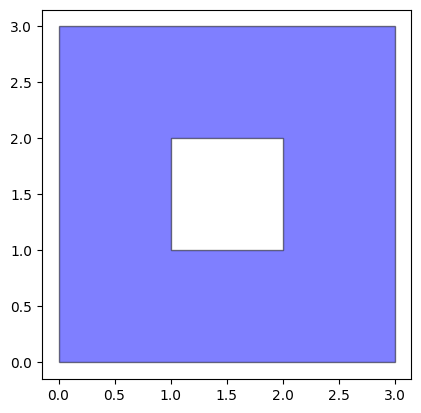

In [80]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)

p3 = set_ops.difference(p1, p2)
print(f"{p3.area = }")
p3.plot()

### MultiPolygon

<Axes: >

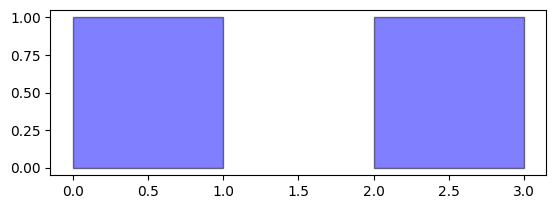

In [81]:
p1 = geometry.Rectangle(0, 0, 3, 1)
p2 = geometry.Rectangle(1, -1, 1, 3)
p3 = set_ops.difference(p1, p2)

fig, ax = plt.subplots()
p3.plot(ax=ax)

# Set operations

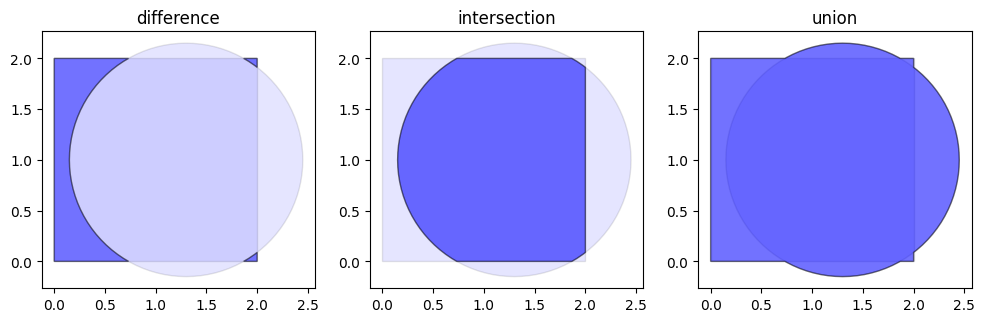

In [82]:
p1 = geometry.Rectangle(0.0, 0.0, 2.0, 2.0)
p2 = geometry.Circle(1.3, 1.0, 1.15, num_edges=100)

diff_poly = set_ops.difference(p1, p2)
intersection_poly = set_ops.intersection(p1, p2)
union_poly = set_ops.union([p1, p2])

_, ax = plt.subplots(figsize=(12, 4), ncols=3)

for i in range(3):
    ax[i].set_aspect('equal')
    p1.plot(ax[i], alpha=0.1)
    p2.plot(ax[i], alpha=0.1)

diff_poly.plot(ax[0], color='blue')
ax[0].set_title('difference')
intersection_poly.plot(ax[1], color='blue')
ax[1].set_title('intersection')
union_poly.plot(ax[2], color='blue')
ax[2].set_title('union')

plt.show()

# Mutation

### Expansion

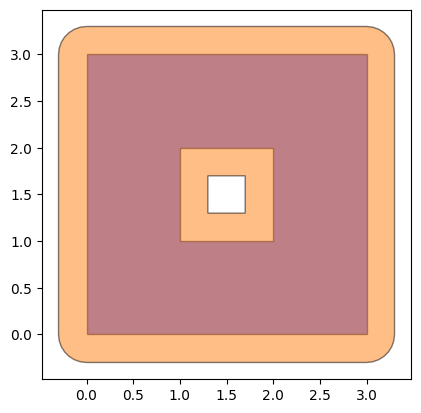

In [85]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)
p3 = set_ops.difference(p1, p2)
p4 = mutation.buffer(p3, 0.3)

fig, ax = plt.subplots()
p3.plot(ax=ax)
p4.plot(ax=ax, color='tab:orange');

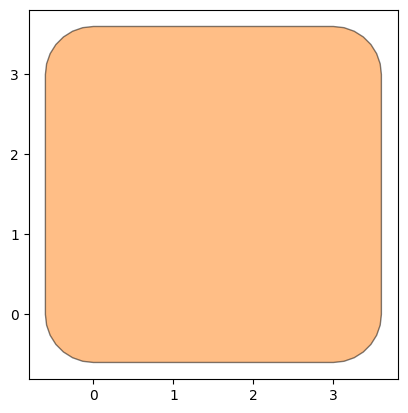

In [88]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)
p3 = set_ops.difference(p1, p2)
p4 = mutation.buffer(p3, 0.6)

fig, ax = plt.subplots()
p4.plot(ax=ax, color='tab:orange');

### Shrinkage

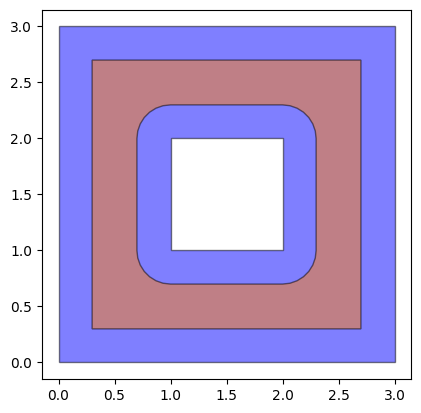

In [84]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)
p3 = set_ops.difference(p1, p2)
p4 = mutation.buffer(p3, -0.3)

fig, ax = plt.subplots()
p3.plot(ax=ax)
p4.plot(ax=ax, color='tab:orange');

### L shape

0.5795775
False


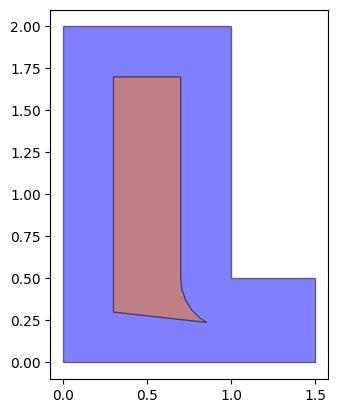

In [92]:
vertices = jnp.array(
    [[0.0, 0.0], [1.5, 0.0], [1.5, 0.5], [1.0, 0.5], [1.0, 2.0], [0.0, 2.0]],
    dtype=jnp.float32,
)
p1 = geometry.Polygon(vertices=vertices)
p2 = mutation.buffer(p1, -0.3)

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax, color='tab:orange')
print(p2.area)
print(p2.self_intersect)

# Plotting using plotly

In [95]:
p1 = geometry.Circle(0, 0, 1.15, num_edges=100)
p2 = mutation.buffer(p1, -1.0)
print(f'{p2.area = }')
plotting.plot_polygons([p1, p2])

p2.area = Array(0.0701751, dtype=float32)


# Staircase

p1.area = Array(0.5, dtype=float32)
p2.area = Array(1.306474, dtype=float32)


<Axes: >

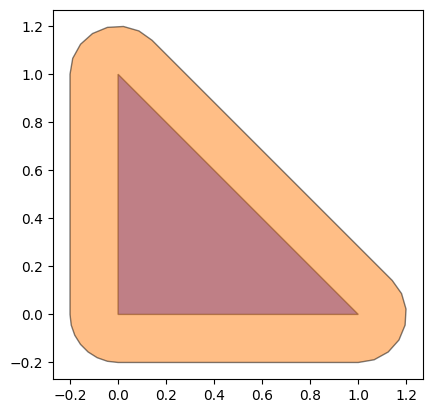

In [96]:
p1 = geometry.Polygon(
    vertices=jnp.array(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
        ]
    )
)
p2 = mutation.buffer(p1, 0.2)
print(f"{p1.area = }")
print(f"{p2.area = }")

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax, color='tab:orange')

# Multiple staircases

In [98]:
p1 = geometry.Polygon(vertices=jnp.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]]))
p2 = mutation.buffer(p1, 0.2)
p3 = mutation.offset(p2, 1.0, 0.0)
p4 = mutation.offset(p2, -1.0, 0.0)
p5 = set_ops.union([p2, p3, p4])
print(f"{p5.area = }")
plotting.plot_polygons(p5)

p5.area = Array(3.5715003, dtype=float32)
